In [1]:
!pip install -q transformers

In [2]:
from transformers import RobertaTokenizerFast, TFRobertaForSequenceClassification, pipeline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
sentiment_pipeline = pipeline("sentiment-analysis")
data = ["I love you", "I hate you"]
sentiment_pipeline(data)

In [ ]:
# download pre-trained emotion classification model
emotion = pipeline("text-classification", model="j-hartmann/emotion-english-distilroberta-base")

emotion(data)

In [6]:
df = pd.read_csv('Water7.csv')

In [7]:
df.head(5)

,web-scraper-order,web-scraper-start-url,link,link-href,comment
0,1735058309-9,https://transcripts.foreverdreaming.org/viewfo...,07x207 - Great Adventure in Long Ring Long Land!,https://transcripts.foreverdreaming.org/viewto...,LONGRING LONGLAND!\n\n\n\n THE GREAT ADVENTURE...
1,1735058311-10,https://transcripts.foreverdreaming.org/viewfo...,07x208 - A Davy Back with the Foxy Pirates!,https://transcripts.foreverdreaming.org/viewto...,PIRATE FOXY DAVY BACK FIGHT!\n\n\n\n !\n\n\n\n...
2,1735058315-11,https://transcripts.foreverdreaming.org/viewfo...,07x209 - Round 1! One Lap of the Donut Race!,https://transcripts.foreverdreaming.org/viewto...,FIRST ROUND!\n\n\n\n THE DONUT RACE Brothel.\n...
3,1735058318-12,https://transcripts.foreverdreaming.org/viewfo...,07x210 - Silver Fox Foxy! The Merciless Interf...,https://transcripts.foreverdreaming.org/viewto...,FOXY THE SILVER FOX!\n\n\n\n AN INTERVENTION F...
4,1735058320-13,https://transcripts.foreverdreaming.org/viewfo...,07x211 - Round 2! sh**t It into the Groggy Ring!,https://transcripts.foreverdreaming.org/viewto...,Luffy accepted Davy Back Fight which opposes i...


In [8]:
df.drop(['web-scraper-order', 'web-scraper-start-url'], axis=1, inplace=True)

In [9]:
df.head(5)

,link,link-href,comment
0,07x207 - Great Adventure in Long Ring Long Land!,https://transcripts.foreverdreaming.org/viewto...,LONGRING LONGLAND!\n\n\n\n THE GREAT ADVENTURE...
1,07x208 - A Davy Back with the Foxy Pirates!,https://transcripts.foreverdreaming.org/viewto...,PIRATE FOXY DAVY BACK FIGHT!\n\n\n\n !\n\n\n\n...
2,07x209 - Round 1! One Lap of the Donut Race!,https://transcripts.foreverdreaming.org/viewto...,FIRST ROUND!\n\n\n\n THE DONUT RACE Brothel.\n...
3,07x210 - Silver Fox Foxy! The Merciless Interf...,https://transcripts.foreverdreaming.org/viewto...,FOXY THE SILVER FOX!\n\n\n\n AN INTERVENTION F...
4,07x211 - Round 2! sh**t It into the Groggy Ring!,https://transcripts.foreverdreaming.org/viewto...,Luffy accepted Davy Back Fight which opposes i...


In [10]:
MAX_LENGTH = 512  # ขีดจำกัดของโมเดล
df['comment'] = df['comment'].apply(lambda x: x[:MAX_LENGTH] if isinstance(x, str) else "")
#ตัดข้อความให้สั้นลงก่อนประมวลผล

In [11]:
df['comment'] = df['comment'].str.replace('\n', '').str.replace('\r', '').str.replace('', '').str.replace('Fame', '').str.replace('Wealth', '').str.replace('Power', '').str.replace('', '')

In [12]:
df['sentiment'] = df.comment.apply(lambda x: sentiment_pipeline(x)[0]['label'])

In [13]:
df['emotion'] = df.comment.apply(lambda x: emotion(x)[0]['label'])

In [14]:
df.head(5)

,link,link-href,comment,sentiment,emotion
0,07x207 - Great Adventure in Long Ring Long Land!,https://transcripts.foreverdreaming.org/viewto...,LONGRING LONGLAND! THE GREAT ADVENTURE One mov...,NEGATIVE,joy
1,07x208 - A Davy Back with the Foxy Pirates!,https://transcripts.foreverdreaming.org/viewto...,"PIRATE FOXY DAVY BACK FIGHT! ! One is there, o...",NEGATIVE,anger
2,07x209 - Round 1! One Lap of the Donut Race!,https://transcripts.foreverdreaming.org/viewto...,FIRST ROUND! THE DONUT RACE Brothel. This time...,NEGATIVE,surprise
3,07x210 - Silver Fox Foxy! The Merciless Interf...,https://transcripts.foreverdreaming.org/viewto...,FOXY THE SILVER FOX! AN INTERVENTION FORCES Th...,POSITIVE,surprise
4,07x211 - Round 2! sh**t It into the Groggy Ring!,https://transcripts.foreverdreaming.org/viewto...,Luffy accepted Davy Back Fight which opposes i...,NEGATIVE,surprise


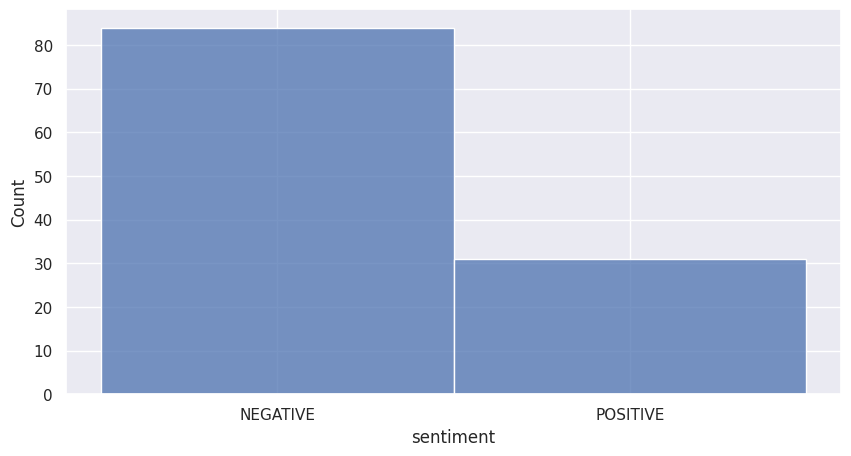

In [15]:
sns.set(rc={'figure.figsize':(10,5)})
fig = sns.histplot(df['sentiment'])

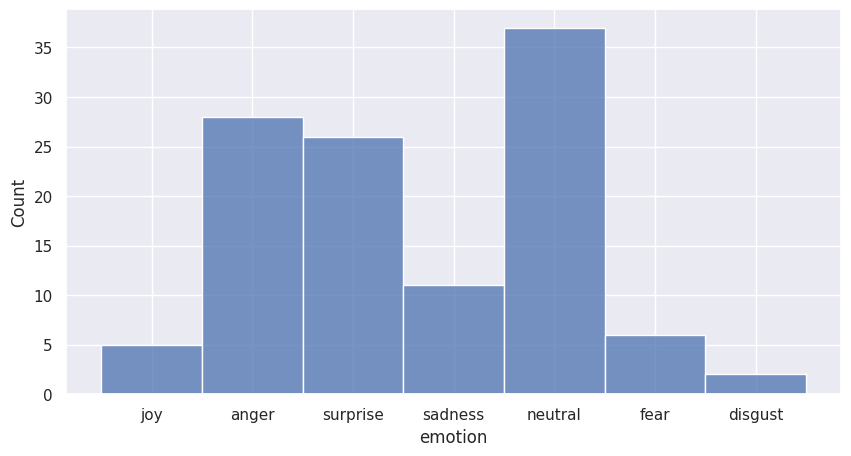

In [ ]:
sns.set(rc={'figure.figsize':(10,5)})
fig = sns.histplot(df['emotion'])

In [16]:
df.to_csv('SoothingRelaxation-done.csv', index=False)

In [17]:
from wordcloud import WordCloud
from wordcloud import STOPWORDS

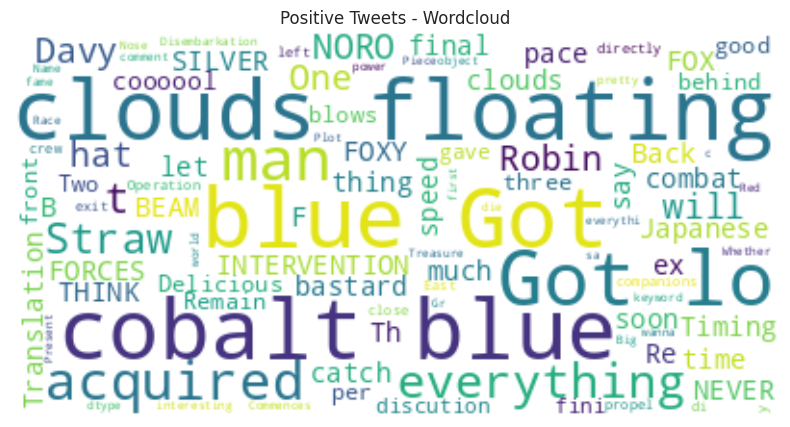

In [18]:
# Wordcloud with positive
msg = df['comment'][df["sentiment"] == 'POSITIVE']
stop_words = list(STOPWORDS)
positive_wordcloud = WordCloud(max_font_size=50, max_words=100, background_color="white", stopwords = stop_words).generate(str(msg))
plt.figure()
plt.title("Positive Tweets - Wordcloud")
plt.imshow(positive_wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()


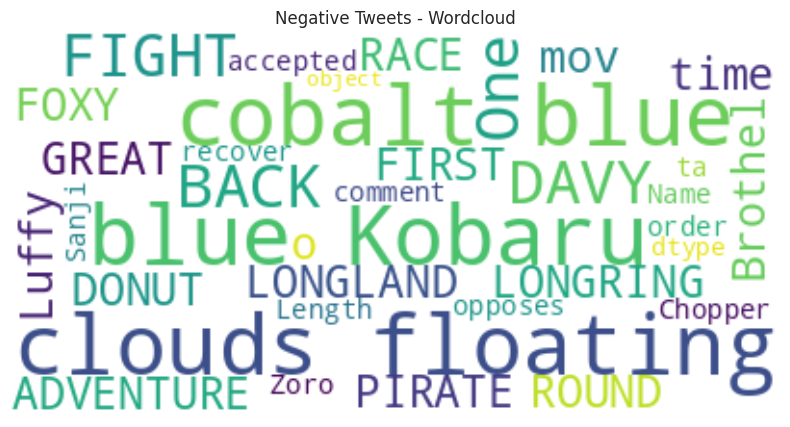

In [19]:
 # Wordcloud with negative
msg = df['comment'][df["sentiment"] == 'NEGATIVE']
stop_words = ["https", "co", "RT"] + list(STOPWORDS)
negative_wordcloud = WordCloud(max_font_size=50, max_words=100, background_color="white", stopwords = stop_words).generate(str(msg))
plt.figure()
plt.title("Negative Tweets - Wordcloud")
plt.imshow(negative_wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()


In [ ]:
msg = df['comment']
stop_words = ["https", "co", "RT"] + list(STOPWORDS)
negative_wordcloud = WordCloud(max_font_size=50, max_words=100, background_color="white", stopwords = stop_words).generate(str(msg))
plt.figure()
plt.title("Negative Tweets - Wordcloud")
plt.imshow(negative_wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()


In [ ]:
msg = df['comment'][df['emotion'] == 'JOY']
stop_words = ["https", "co", "RT"] + list(STOPWORDS)
negative_wordcloud = WordCloud(max_font_size=50, max_words=100, background_color="white", stopwords = stop_words).generate(str(msg))
plt.figure()
plt.title("Negative Tweets - Wordcloud")
plt.imshow(negative_wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()
